In [1]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks

In [2]:
def display_image_grayscale(image):
  plt.imshow(image, cmap='gray', vmin=0, vmax=255)
  plt.axis('off')
  plt.show()

def display_image_color(image):
  plt.imshow(image)
  plt.axis('off')
  plt.show()


In [3]:
def create_gaussian_kernel(L, sigma):
    '''This function creates a gaussian kernel used for smoothing'''
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    midpoint = L // 2
    kernel = [[0 for _ in range(L)] for _ in range(L)]
    total = 0
    for i in range(L):
        for j in range(L):
            y = (i - midpoint)
            x = (j - midpoint)
            value = (1/(2*math.pi*sigma**2)) * math.exp(-(x**2 + y**2)/(2*sigma**2))
            kernel[i][j] = value
            total += value
    for i in range(L):
        for j in range(L):
            kernel[i][j] /= total # Normalization
    return np.array(kernel)

In [4]:
@njit
def _apply_kernel(padded_image, kernel, padding_size):
    '''This function performs kernel operations for linear image filters. 
    It is a helper function for the convolution function
    It uses numba to optimize the function into optimized machine code
    '''
    N, M = padded_image.shape
    filtered_image = np.zeros_like(padded_image)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            image_window = padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            newPixel = np.sum(image_window * kernel)
            filtered_image[i, j] = newPixel
    return filtered_image


def linear_filter(image, kernel, clip=True):
    '''This function is a general image filter that works for various kernels
    Set clip=False for mathematical derivatives (Harris/Sobel).'''
    def convolution(image, kernel):
        L = len(kernel)
        padding_size = (L - 1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_kernel(padded_image, kernel, padding_size)
        filtered_image = filtered_image[padding_size: -padding_size, padding_size: -padding_size]
        if clip:
            return np.clip(filtered_image, 0, 255).astype(np.uint8)
        else:
            return filtered_image # Returns raw float32 values
    
    if len(kernel) % 2 == 0 or len(kernel) <= 0:
        print("Kernel size must be an odd integer")
        return None

    if len(image.shape) == 3: # RGB/BGR images
        channels = [convolution(image[:, :, i], kernel) for i in range(3)]
        return np.dstack(channels)
    else: # Grayscale images
        return convolution(image, kernel)

In [5]:
@njit
def _apply_median_kernel(padded_image, L, padding_size):
    '''This function performs kernel operations for median image filters.
    It uses numba to optimize the function into optimized machine code
    '''
    N, M = padded_image.shape
    im_filtered = np.zeros_like(padded_image)
    for i in range(padding_size, N-padding_size):
        for j in range(padding_size, M-padding_size):
            median = np.median(padded_image[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1])
            im_filtered[i, j] = median
    return im_filtered


def median_filter(image, L):
    '''Non-linear filter used for calculating the median value in a kernel. Useful for removing salt and pepper noise'''
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    if len(image.shape) == 2: # only grayscale images
        padding_size = (L-1) // 2
        padded_image = np.pad(image, pad_width=padding_size, mode='edge').astype(np.float32)
        filtered_image = _apply_median_kernel(padded_image, L, padding_size)
        return np.clip(filtered_image[padding_size: -padding_size, padding_size: -padding_size], 0, 255).astype(np.uint8)
    

In [6]:
def create_histogram(image, bin_size):
    '''Creates a (denormalized) histogram of an image. 
    The bin_size is the number of intensity levels and the histogram contains occurrences of each intensity level.
    '''
    np.bincount(image.ravel(), minlength=bin_size)
    hist = [0 for i in range(bin_size)]
    bin = [i for i in range(bin_size)]
    for i in range(len(image)):
        for j in range(len(image[i])):
            hist[image[i][j]] += 1
    return hist, bin

def create_normalized_histogram(image, bin_size):
    '''Creates a normalized histogram of an image. 
    The bin_size is the number of intensity levels and the histogram contains normalized occurrences of each intensity level.
    '''
    N,M = image.shape
    hist_norm = [0 for i in range(bin_size)]
    bin = [i for i in range(bin_size)]
    for i in range(len(image)):
        for j in range(len(image[i])):
            hist_norm[image[i][j]] += (1 / (N*M))
    return hist_norm, bin

In [7]:
def find_otsu_threshold(hist_norm):
    '''Finds the most optimal global threshold of an image using Otsu's algorithm
    Returns the optimal threshold value.'''
    def calculate_between_class_variance(hist_norm, T):
        # Todo: This function needs to be optimized in terms of time complexity
        P1, sum1 = 0, 0
        P2, sum2 = 0, 0
        for i in range(len(hist_norm)):
            if i < T:
                sum1 += (i * hist_norm[i])
                P1 += hist_norm[i]
            else:
                sum2 += (i * hist_norm[i])
                P2 += hist_norm[i]
        if P1 == 0 or P2 == 0:
            return 0
        m1 = sum1 / P1
        m2 = sum2 / P2
        variance = (P1*P2) * (m1-m2)**2
        return variance
    
    max_variance = 0
    best_threshold = 0
    for i in range(len(hist_norm)):
        variance = calculate_between_class_variance(hist_norm, i) # Todo: This line needs to be optimized
        if variance > max_variance:
            max_variance = variance
            best_threshold = i
    return best_threshold

def perform_threshold(image, threshold):
    '''Applies global thresholding to an image and returns the image'''
    N, M = image.shape
    image_threshold = np.zeros((N, M))
    for i in range(len(image_threshold)):
        for j in range(len(image_threshold[i])):
            if image[i][j] > threshold:
                image_threshold[i][j] = 255
            else:
                image_threshold[i][j] = 0
    return image_threshold

In [9]:
def harris_corners(img, window_size=3, k=0.04):
    '''
    Custom function implemented from the lab.
    The original lab uses filters.sobel_v(img) and filters.sobel_h(img) from skimage library.
    In this implementation, we're using custom linear_filter with sobel gradient
    '''
    H, W = img.shape
    window = np.ones((window_size, window_size))
    padding_size = (window_size-1) // 2
    response = np.zeros((H, W))

    # 1. Compute x and y derivatives (I_x, I_y) of an image
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    I_x = linear_filter(img, kernel_x, False)
    I_y = linear_filter(img, kernel_y, False)

    for i in range(padding_size, H-padding_size):
        for j in range(padding_size, W-padding_size):
            I_x_squared = np.square(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_y_squared = np.square(I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            I_x_y = np.multiply(I_x[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1], I_y[i-padding_size: i+padding_size+1, j-padding_size: j+padding_size+1])
            
            for a in range(window_size):
                for b in range(window_size):
                    I_x_squared[a][b] = window[a][b] * I_x_squared[a][b]
                    I_y_squared[a][b] = window[a][b] * I_y_squared[a][b]
                    I_x_y[a][b] = window[a][b] * I_x_y[a][b]


            sum_I_x_squared = np.sum(I_x_squared)
            sum_I_y_squared = np.sum(I_y_squared)
            sum_I_x_I_y = np.sum(I_x_y)
            determinant = sum_I_x_squared * sum_I_y_squared - sum_I_x_I_y * sum_I_x_I_y
            trace = sum_I_x_squared + sum_I_y_squared
            response[i][j] = determinant - (k * trace * trace)

    return response

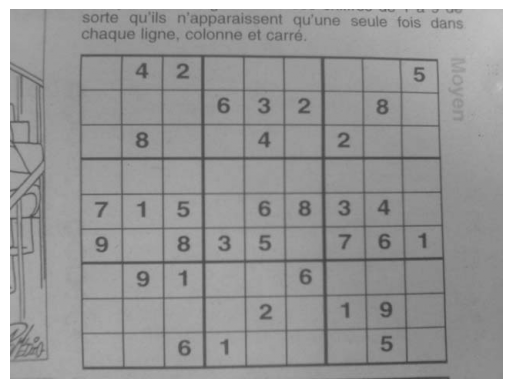

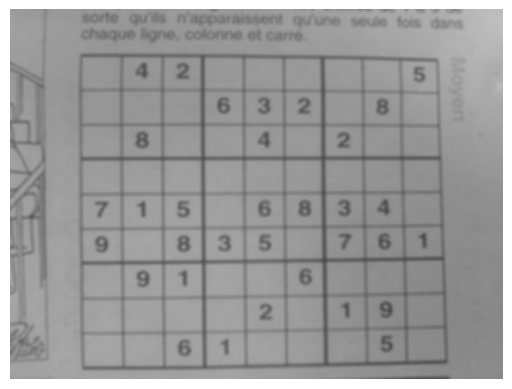

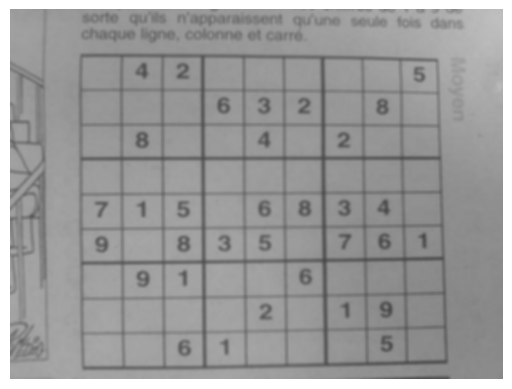

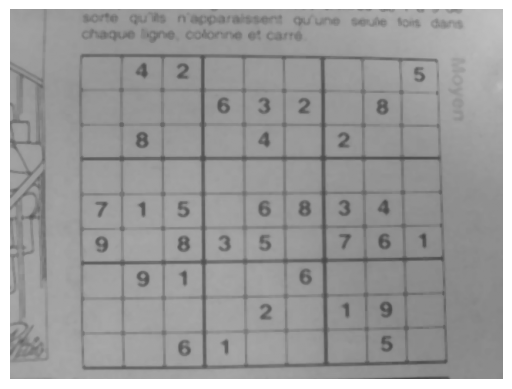

In [10]:
image = cv2.imread("images/image10.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(L, 3)

blurred_image = linear_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = linear_filter(image, gaussian_kernel)

display_image_grayscale(image)
display_image_grayscale(blurred_image)
display_image_grayscale(gaussian_image)
display_image_grayscale(median_filter_image)

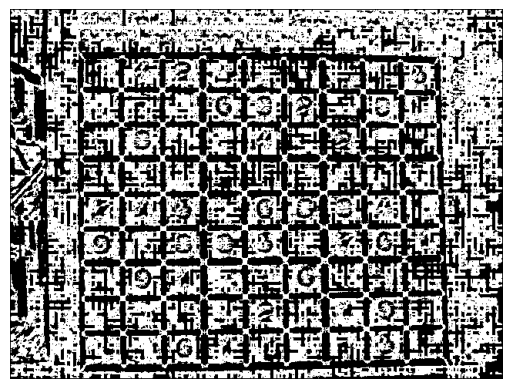

In [11]:
img = imread('images/tictactoe.png', as_gray=True)

# Compute Harris corner response
response = harris_corners(image)

display_image_grayscale(response)

Text(0.5, 1.0, 'Detected Corners')

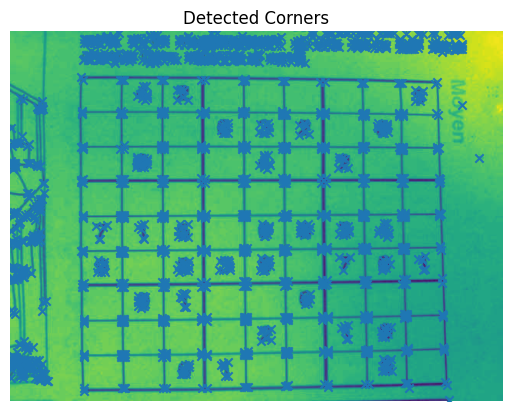

In [12]:
corners = corner_peaks(response, threshold_rel=0.01)

# Display detected corners
plt.imshow(image)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

In [8]:
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

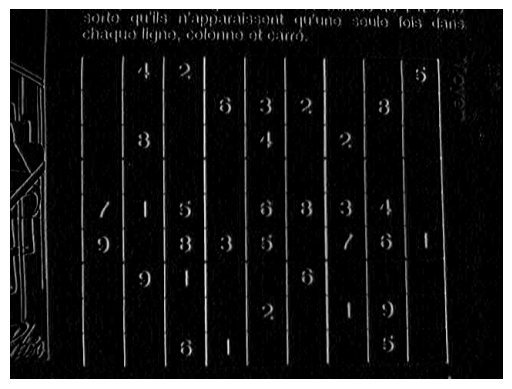

In [13]:
image_sobel_x = linear_filter(image, sobel_x_kernel)
image_sobel_y = linear_filter(image, sobel_y_kernel)
display_image_grayscale(image_sobel_x)

131


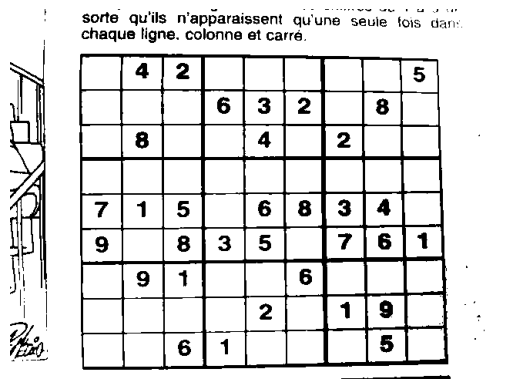

In [14]:
(hist, bin) = create_normalized_histogram(image, 256)
threshold_val = find_otsu_threshold(hist)
print(threshold_val)
image_thresh = perform_threshold(image, threshold_val)
display_image_grayscale(image_thresh)

136


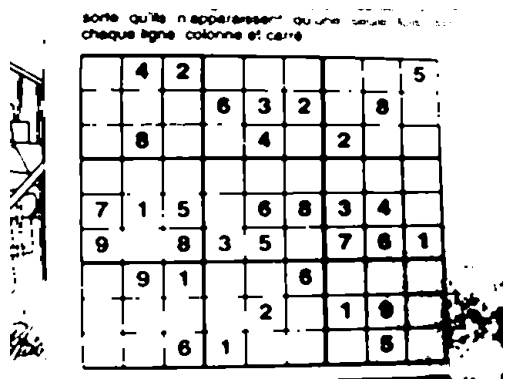

In [15]:
(hist, bin) = create_normalized_histogram(median_filter_image, 256)
threshold_val = find_otsu_threshold(hist)
print(threshold_val)
image_thresh_1 = perform_threshold(median_filter_image, threshold_val)
display_image_grayscale(image_thresh_1)